# Problem Set 6 for MSDM 5003

Author: LAN, Tianwei 藍天蔚<br>
ID: 21230969<br>
Email: tlanaa@connect.ust.hk

# (1) Download stock price and calculate $R_i(t)$

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ['NVDA', 'AAPL', 'MSFT', 'GOOGL', 'AMZN',
           'AVGO', 'META', 'TSLA', 'BRK-B', 'JPM']

start_date = '2024-08-01'
end_date   = '2025-11-01'

idx = yf.download('NVDA', start=start_date, end=end_date,
                  progress=False, auto_adjust=False).index

stocks = pd.DataFrame(index=idx)

for t in tickers:
    adj = yf.download(t,start = start_date,end = end_date,auto_adjust=False)["Adj Close"]
    stocks[t] = adj

stocks.reset_index(inplace=True)
# stocks.to_csv('stocks.csv', index=False)

prices = stocks.set_index('Date')
log_ret_0 = np.log(prices.shift(-1) / prices)
# log_ret_0.reset_index().to_csv('log_returns.csv', index=False)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


# (2)Correlation matrix of 10 stocks

In [166]:
log_ret = log_ret_0.loc['2024-08-01':'2025-08-01']
corr_mtx = log_ret.corr()

with np.printoptions(precision=3, suppress=True):
    print(corr_mtx.values)

# corr_mtx.to_csv('corr_matrix.csv')

[[1.    0.444 0.628 0.504 0.569 0.682 0.565 0.46  0.178 0.42 ]
 [0.444 1.    0.566 0.494 0.578 0.382 0.553 0.481 0.431 0.474]
 [0.628 0.566 1.    0.541 0.703 0.522 0.683 0.466 0.291 0.454]
 [0.504 0.494 0.541 1.    0.63  0.466 0.54  0.522 0.205 0.405]
 [0.569 0.578 0.703 0.63  1.    0.541 0.726 0.519 0.344 0.557]
 [0.682 0.382 0.522 0.466 0.541 1.    0.517 0.454 0.132 0.365]
 [0.565 0.553 0.683 0.54  0.726 0.517 1.    0.483 0.247 0.474]
 [0.46  0.481 0.466 0.522 0.519 0.454 0.483 1.    0.344 0.462]
 [0.178 0.431 0.291 0.205 0.344 0.132 0.247 0.344 1.    0.624]
 [0.42  0.474 0.454 0.405 0.557 0.365 0.474 0.462 0.624 1.   ]]


# (3)(4) Compute and output eigenvalues and eigenvectors in descending order

This is actually doing PCA.

In [167]:
corr_vals = corr_mtx.values
eig_vals, eig_vecs = np.linalg.eigh(corr_vals)

desc_idx = np.argsort(eig_vals)[::-1]
eig_vals_sorted  = eig_vals[desc_idx]
eig_vecs_sorted  = eig_vecs[:, desc_idx]

with np.printoptions(precision=3, suppress=True):
    print("Sorted eigenvalues (descending):")
    print(eig_vals_sorted)
    print("\nSorted eigenvectors (columns correspond to above eigenvalues):")
    print(eig_vecs_sorted)

Sorted eigenvalues (descending):
[5.406 1.228 0.664 0.619 0.483 0.432 0.354 0.313 0.266 0.235]

Sorted eigenvectors (columns correspond to above eigenvalues):
[[-0.325  0.299  0.416 -0.149 -0.144 -0.165  0.388 -0.425 -0.355 -0.324]
 [-0.317 -0.175 -0.37  -0.028 -0.712 -0.305 -0.279 -0.201  0.112 -0.026]
 [-0.351  0.13  -0.188 -0.327 -0.066  0.163  0.596  0.175  0.415  0.359]
 [-0.316  0.146 -0.307  0.445  0.409 -0.585  0.107  0.051 -0.153  0.199]
 [-0.369  0.042 -0.223 -0.14   0.292  0.099 -0.154  0.235  0.241 -0.749]
 [-0.301  0.345  0.558 -0.011 -0.122 -0.144 -0.421  0.444  0.155  0.212]
 [-0.348  0.134 -0.274 -0.258  0.13   0.439 -0.321 -0.063 -0.569  0.28 ]
 [-0.303 -0.069  0.104  0.752 -0.179  0.525  0.112 -0.038  0.062 -0.042]
 [-0.205 -0.709  0.191 -0.091 -0.053 -0.108  0.209  0.462 -0.371 -0.032]
 [-0.3   -0.443  0.279 -0.11   0.385 -0.015 -0.209 -0.525  0.344  0.197]]


# (5) Plot the eigenvalues of the eigenmodes versus the eigenmode numbers

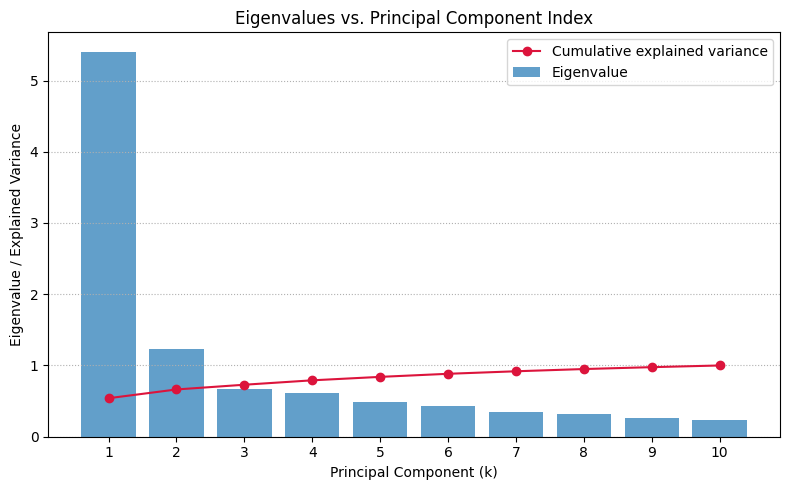

In [168]:
import matplotlib.pyplot as plt

n = len(eig_vals_sorted)
pc_idx = np.arange(1, n+1)
var_exp = eig_vals_sorted / n
cum_var = np.cumsum(var_exp)

plt.figure(figsize=(8, 5))
plt.bar(pc_idx, eig_vals_sorted, alpha=0.7, label='Eigenvalue')
plt.plot(pc_idx, cum_var, color='crimson', marker='o', label='Cumulative explained variance')

plt.title('Eigenvalues vs. Principal Component Index')
plt.xlabel('Principal Component (k)')
plt.ylabel('Eigenvalue / Explained Variance')
plt.xticks(pc_idx)
plt.grid(axis='y', ls=':')
plt.legend()
plt.tight_layout()
# plt.savefig('scree_plot.png')
plt.show()

# (6) Compute cumulative variance of eigenmodes and N (cum_var > 0.8)

In [95]:
var_exp = eig_vals_sorted / eig_vals_sorted.sum()
cum_var = np.cumsum(var_exp)
n_below = (cum_var < 0.80).sum()
N = int(n_below)
print(f'N = {N}')

N = 4


# (7) Cluster visualization and comment

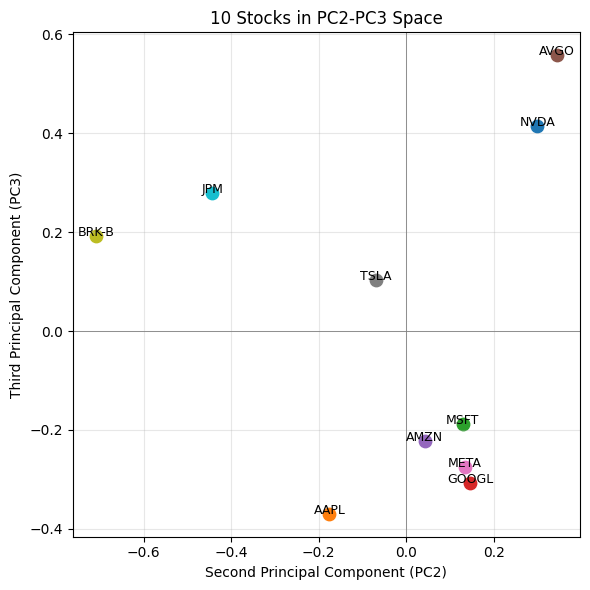

In [169]:
pc2_load = eig_vecs_sorted[:, 1]
pc3_load = eig_vecs_sorted[:, 2]

plt.figure(figsize=(6,6))
for i, ticker in enumerate(prices.columns):
    plt.scatter(pc2_load[i], pc3_load[i], s=80)
    plt.text(pc2_load[i], pc3_load[i], ticker, fontsize=9, ha='center')

plt.axhline(0, color='gray', lw=0.6)
plt.axvline(0, color='gray', lw=0.6)
plt.title('10 Stocks in PC2-PC3 Space')
plt.xlabel('Second Principal Component (PC2)')
plt.ylabel('Third Principal Component (PC3)')
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('PC2_PC3_map.png')
plt.show()

I see four clear groups in the chart.
1. Top-right (NVDA, AVGO)<br>These are the energetic, high-growth chip names. When optimism rises, they spike first.

2. Top-left (BRK-B, JPM)<br>Old-style value and finance firms. They prefer steady times and offer calm, reliable dividends.

3. Near the middle (TSLA)<br>A lone, event-driven name. It doesn’t line up with either growth or safety trends, so it hovers around the center.

4. Bottom-center (MSFT, AMZN, META, AAPL, GOOGL)<br>Big tech giants with smoother moves. You still get tech exposure, but with less bounce than the chip duo.

Overall, the map stretches from “excited and jumpy” to “steady and quiet.” Choosing stocks from opposite corners blends those moods and helps keep a portfolio balanced.

# (8) Stock investment with equal weight strategy

To validate this strategy, a principal of $ 1 million will be used. February 2, 2025, is a non-trading day; the most recent closing and opening dates are January 31 and February 3, respectively.

In [170]:
# Initial condition
cash = 1_000_000
weights = pd.DataFrame(index=prices.index, columns=tickers)
shares  = pd.DataFrame(index=prices.index, columns=tickers)
nav = pd.Series(index=prices.index, name='EqualWeight_NAV')

# Open position
first_day = prices.index[0]
shares.loc[first_day] = (cash * 0.1) / prices.loc[first_day]
weights.loc[first_day] = 0.1
nav.loc[first_day] = (shares.loc[first_day] * prices.loc[first_day]).sum()

for t in prices.index[1:]:
    # Inheriting yesterday's share count
    shares.loc[t] = shares.iloc[shares.index.get_loc(t)-1]
    # Calculate today's market capitalization & weighting
    values = shares.loc[t] * prices.loc[t]
    nav.loc[t] = values.sum()
    weights.loc[t] = values / nav.loc[t]

    # Rebalancing Day: Bring the weights back to 10%.
    if t.strftime('%Y-%m-%d') == "2025-02-03": # the 1st trading day after 2/2/2025
        target_value = nav.loc[t] * 0.1
        shares.loc[t] = target_value / prices.loc[t]   # New target share count
        weights.loc[t] = 0.1

nav = nav.reset_index().rename(columns={'index': 'Date'})
nav_1 = nav

print('Previous day\'s weights (2025-02-02):')
print(weights.loc['2025-01-31'].apply(lambda x: f'{x:.1%}'))
print('\nNext day\'s weights (2025-02-03):')
print(weights.loc["2025-02-03"].apply(lambda x: f'{x:.1%}'))

Previous day's weights (2025-02-02):
NVDA      8.6%
AAPL      8.4%
MSFT      7.8%
GOOGL     9.3%
AMZN     10.1%
AVGO     11.8%
META     10.8%
TSLA     14.6%
BRK-B     8.5%
JPM      10.1%
Name: 2025-01-31 00:00:00, dtype: object

Next day's weights (2025-02-03):
NVDA     10.0%
AAPL     10.0%
MSFT     10.0%
GOOGL    10.0%
AMZN     10.0%
AVGO     10.0%
META     10.0%
TSLA     10.0%
BRK-B    10.0%
JPM      10.0%
Name: 2025-02-03 00:00:00, dtype: object


In [171]:
# Without rebalancing
shares_n = (cash * 0.1) / prices.iloc[0]
nav_n = (shares_n * prices).sum(axis=1)
nav_n = nav_n.reset_index().rename(columns={'index': 'Date', 0:'Original_NAV'})
# print(nav_n)

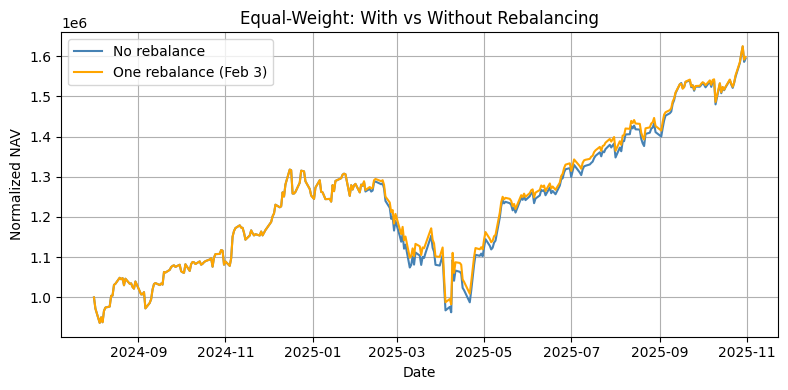

In [172]:
# Plot
plt.figure(figsize=(8,4))
plt.plot(nav_n['Date'], nav_n['Original_NAV'], label='No rebalance', color='steelblue')
plt.plot(nav['Date'], nav['EqualWeight_NAV'], label='One rebalance (Feb 3)', color='orange')
plt.title('Equal-Weight: With vs Without Rebalancing')
plt.xlabel('Date')
plt.ylabel('Normalized NAV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Judging from the results, rebalancing is a little bit useful.

# (9) Risk Parity

The Risk Parity strategy calculates the standard deviation of each stock based on previous stock price data up to February 2, 2025, and then performs risk-based asset reallocation based on the inverse of the standard deviation. Therefore, the standard deviation calculation and reallocation will only be performed on February 2nd (i.e., within the if condition `if t.strftime('%Y-%m-%d') == "2025-02-03":`).

In [173]:
# Initial condition
cash = 1_000_000
weights = pd.DataFrame(index=prices.index, columns=tickers)
shares  = pd.DataFrame(index=prices.index, columns=tickers)
nav = pd.Series(index=prices.index, name='RiskParity_NAV')

# Open position
first_day = prices.index[0]
shares.loc[first_day] = (cash * 0.1) / prices.loc[first_day]
weights.loc[first_day] = 0.1
nav.loc[first_day] = (shares.loc[first_day] * prices.loc[first_day]).sum()

for t in prices.index[1:]:
    # Inheriting yesterday's share count
    shares.loc[t] = shares.iloc[shares.index.get_loc(t)-1]
    # Calculate today's market capitalization & weighting
    values = shares.loc[t] * prices.loc[t]
    nav.loc[t] = values.sum()
    weights.loc[t] = values / nav.loc[t]

    # Rebalancing Day
    if t.strftime('%Y-%m-%d') == "2025-02-03":
        # std is calculated using only data before 2/2/2025.
        sigma = np.log(prices / prices.shift(1)).dropna()[:t].std() # [:t]
        # Risk parity weight: 1/σ, Normalized
        weights_rp = (1 / sigma) / (1 / sigma).sum()
        # Reallocate capital
        total_value = nav.loc[t]
        shares.loc[t] = (total_value * weights_rp) / prices.loc[t]
        weights.loc[t] = weights_rp

nav = nav.reset_index().rename(columns={'index': 'Date'})
nav_2 = nav

print('Previous day\'s weights (2025-02-02):')
print(weights.loc['2025-01-31'].apply(lambda x: f'{x:.1%}'))
print('\nNext day\'s weights (2025-02-03):')
print(weights.loc["2025-02-03"].apply(lambda x: f'{x:.1%}'))

Previous day's weights (2025-02-02):
NVDA      8.6%
AAPL      8.4%
MSFT      7.8%
GOOGL     9.3%
AMZN     10.1%
AVGO     11.8%
META     10.8%
TSLA     14.6%
BRK-B     8.5%
JPM      10.1%
Name: 2025-01-31 00:00:00, dtype: object

Next day's weights (2025-02-03):
NVDA      5.3%
AAPL     13.1%
MSFT     12.8%
GOOGL    10.6%
AMZN      9.6%
AVGO      4.7%
META     11.1%
TSLA      4.4%
BRK-B    17.3%
JPM      11.2%
Name: 2025-02-03 00:00:00, dtype: object


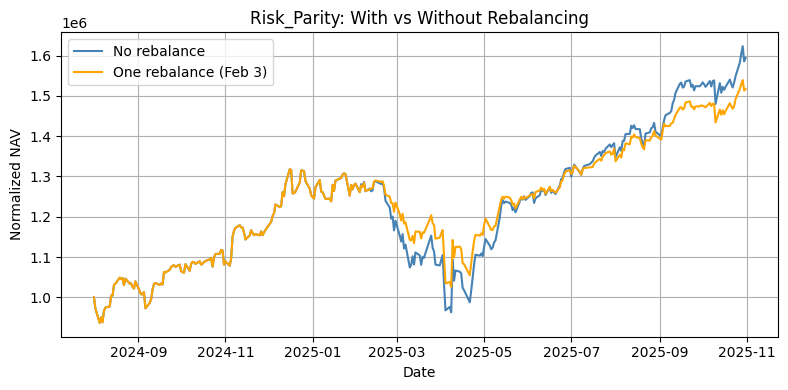

In [174]:
# Plot
plt.figure(figsize=(8,4))
plt.plot(nav_n['Date'], nav_n['Original_NAV'], label='No rebalance', color='steelblue')
plt.plot(nav['Date'], nav['RiskParity_NAV'], label='One rebalance (Feb 3)', color='orange')
plt.title('Risk_Parity: With vs Without Rebalancing')
plt.xlabel('Date')
plt.ylabel('Normalized NAV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

It can be observed that the stock price volatility after rebalancing is significantly lower than that without rebalancing, but the upper limit of returns is also slightly lower.

# (10) Equal Weight Portfolio: Compute projections

In [ ]:
N = 3

# PCA
corr_mtx = log_ret_0.loc["2024-08-01":"2025-02-02"].corr().values # Still use the data before 2/2/2025
eig_vals, eig_vecs = np.linalg.eigh(corr_mtx)
desc_idx = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[desc_idx]
eig_vecs_sorted = eig_vecs[:, desc_idx]

# weights and projections
equal_w = np.ones(10) / 10
projections = equal_w @ eig_vecs_sorted[:, :N]
signs = np.sign(projections)                       # ±1
principal_w = signs * 0.1                          # weights of every stock = ±1/10
print('Projections (first 3 PCs):', projections.round(3))
print('Signed weights:', principal_w.round(3))

Projections (first 3 PCs): [-0.309 -0.051  0.003]
Signed weights: [-0.1 -0.1  0.1]


# (11) Equal Weight Protfolio: Compute weights of each stock

In [176]:
sign_corrected = eig_vecs_sorted[:, :N] * signs

total_w = sign_corrected.sum(axis=1) / N 
total_w /= total_w.sum()

print('Total weight after sign correction：')
print(pd.Series(total_w, index=tickers).apply(lambda x: f'{x:.2%}'))

Total weight after sign correction：
NVDA      11.05%
AAPL     -11.68%
MSFT       0.53%
GOOGL      9.59%
AMZN       8.95%
AVGO      15.59%
META      -1.82%
TSLA      17.04%
BRK-B     22.30%
JPM       28.45%
dtype: object


In [177]:
weight_s = pd.Series(total_w, index=tickers) 
short_list = weight_s[weight_s < 0]
print('\n Short stocks')
for stk, w in short_list.items():
    print(f'{stk}: {w:.2%}')


 Short stocks
AAPL: -11.68%
META: -1.82%


In [178]:
# Initial condition
cash = 1_000_000
weights = pd.DataFrame(index=prices.index, columns=tickers)
shares  = pd.DataFrame(index=prices.index, columns=tickers)
nav = pd.Series(index=prices.index, name='EWP_NAV')

# Open position
first_day = prices.index[0]
shares.loc[first_day] = (cash * 0.1) / prices.loc[first_day]
weights.loc[first_day] = 0.1
nav.loc[first_day] = (shares.loc[first_day] * prices.loc[first_day]).sum()

for t in prices.index[1:]:
    # Inheriting yesterday's share count
    shares.loc[t] = shares.iloc[shares.index.get_loc(t)-1]
    # Calculate today's market capitalization & weighting
    values = shares.loc[t] * prices.loc[t]
    nav.loc[t] = values.sum()
    weights.loc[t] = values / nav.loc[t]

    # Rebalancing Day
    if t.strftime('%Y-%m-%d') == "2025-02-03":
        # Reallocate capital
        total_value = nav.loc[t]
        shares.loc[t] = (total_value * weight_s) / prices.loc[t]
        weights.loc[t] = weight_s

nav = nav.reset_index().rename(columns={'index': 'Date'})
nav_3 = nav

print('Previous day\'s weights (2025-02-02):')
print(weights.loc['2025-01-31'].apply(lambda x: f'{x:.1%}'))
print('\nNext day\'s weights (2025-02-03):')
print(weights.loc["2025-02-03"].apply(lambda x: f'{x:.1%}'))

Previous day's weights (2025-02-02):
NVDA      8.6%
AAPL      8.4%
MSFT      7.8%
GOOGL     9.3%
AMZN     10.1%
AVGO     11.8%
META     10.8%
TSLA     14.6%
BRK-B     8.5%
JPM      10.1%
Name: 2025-01-31 00:00:00, dtype: object

Next day's weights (2025-02-03):
NVDA      11.0%
AAPL     -11.7%
MSFT       0.5%
GOOGL      9.6%
AMZN       9.0%
AVGO      15.6%
META      -1.8%
TSLA      17.0%
BRK-B     22.3%
JPM       28.5%
Name: 2025-02-03 00:00:00, dtype: object


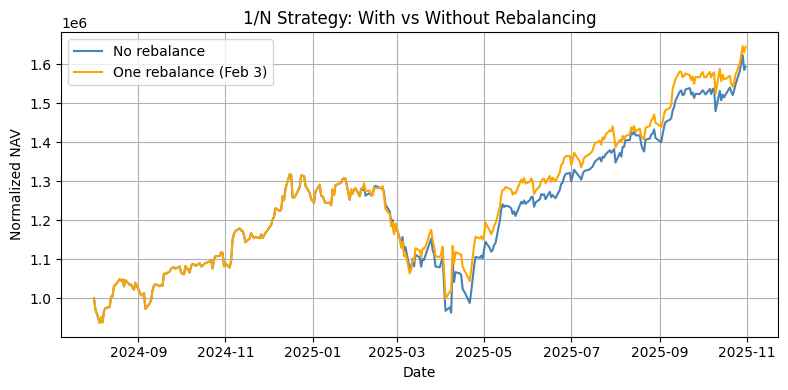

In [179]:
# Plot
plt.figure(figsize=(8,4))
plt.plot(nav_n['Date'], nav_n['Original_NAV'], label='No rebalance', color='steelblue')
plt.plot(nav['Date'], nav['EWP_NAV'], label='One rebalance (Feb 3)', color='orange')
plt.title('1/N Strategy: With vs Without Rebalancing')
plt.xlabel('Date')
plt.ylabel('Normalized NAV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The results show that, due to the hedging between long and short positions, the net asset value curves for rebalanced and unbalanced positions are not completely consistent, and the rebalanced curve exhibits less volatility.

# (13) Diversified Risk Parity

In [180]:
sign_corrected = eig_vecs_sorted[:, :N] * signs # eig_vecs_sorted here is computed base on data before 2/2/2025

pc_risk_w = 1 / eig_vals_sorted[:N]
pc_risk_w /= pc_risk_w.sum()

total_w = (sign_corrected * pc_risk_w).sum(axis=1)
total_w /= total_w.sum()

print('DRP_Risk：')
print(pd.Series(total_w, index=tickers).apply(lambda x: f'{x:.2%}'))

DRP_Risk：
NVDA      23.48%
AAPL     -57.29%
MSFT     -21.18%
GOOGL      9.70%
AMZN       1.08%
AVGO      40.09%
META     -25.02%
TSLA      32.07%
BRK-B     38.66%
JPM       58.41%
dtype: object


In [181]:
# Initial condition
cash = 1_000_000
weights = pd.DataFrame(index=prices.index, columns=tickers)
shares  = pd.DataFrame(index=prices.index, columns=tickers)
nav = pd.Series(index=prices.index, name='DRP_NAV')

# Open position
first_day = prices.index[0]
shares.loc[first_day] = (cash * 0.1) / prices.loc[first_day]
weights.loc[first_day] = 0.1
nav.loc[first_day] = (shares.loc[first_day] * prices.loc[first_day]).sum()

weight_s = pd.Series(total_w, index=tickers) 

for t in prices.index[1:]:
    # Inheriting yesterday's share count
    shares.loc[t] = shares.iloc[shares.index.get_loc(t)-1]
    # Calculate today's market capitalization & weighting
    values = shares.loc[t] * prices.loc[t]
    nav.loc[t] = values.sum()
    weights.loc[t] = values / nav.loc[t]

    # Rebalancing Day
    if t.strftime('%Y-%m-%d') == "2025-02-03":
        # Reallocate capital
        total_value = nav.loc[t]
        shares.loc[t] = (total_value * weight_s) / prices.loc[t]
        weights.loc[t] = weight_s

nav = nav.reset_index().rename(columns={'index': 'Date'})
nav_4 = nav

print('Previous day\'s weights (2025-02-02):')
print(weights.loc['2025-01-31'].apply(lambda x: f'{x:.1%}'))
print('\nNext day\'s weights (2025-02-03):')
print(weights.loc["2025-02-03"].apply(lambda x: f'{x:.1%}'))

Previous day's weights (2025-02-02):
NVDA      8.6%
AAPL      8.4%
MSFT      7.8%
GOOGL     9.3%
AMZN     10.1%
AVGO     11.8%
META     10.8%
TSLA     14.6%
BRK-B     8.5%
JPM      10.1%
Name: 2025-01-31 00:00:00, dtype: object

Next day's weights (2025-02-03):
NVDA      23.5%
AAPL     -57.3%
MSFT     -21.2%
GOOGL      9.7%
AMZN       1.1%
AVGO      40.1%
META     -25.0%
TSLA      32.1%
BRK-B     38.7%
JPM       58.4%
Name: 2025-02-03 00:00:00, dtype: object


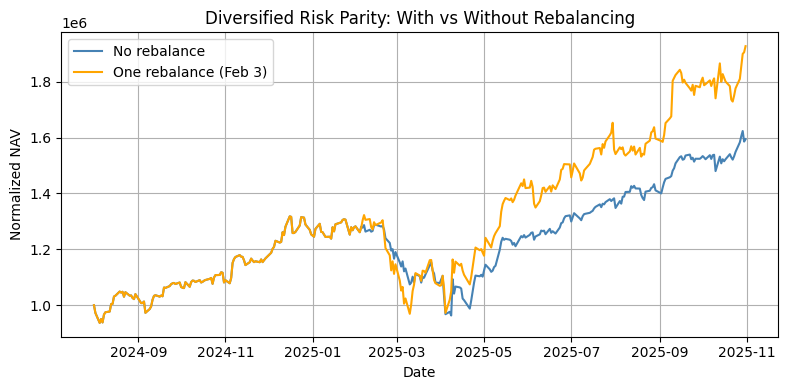

In [182]:
# Plot
plt.figure(figsize=(8,4))
plt.plot(nav_n['Date'], nav_n['Original_NAV'], label='No rebalance', color='steelblue')
plt.plot(nav['Date'], nav['DRP_NAV'], label='One rebalance (Feb 3)', color='orange')
plt.title('Diversified Risk Parity: With vs Without Rebalancing')
plt.xlabel('Date')
plt.ylabel('Normalized NAV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# (14) Compare the strategies by ploting

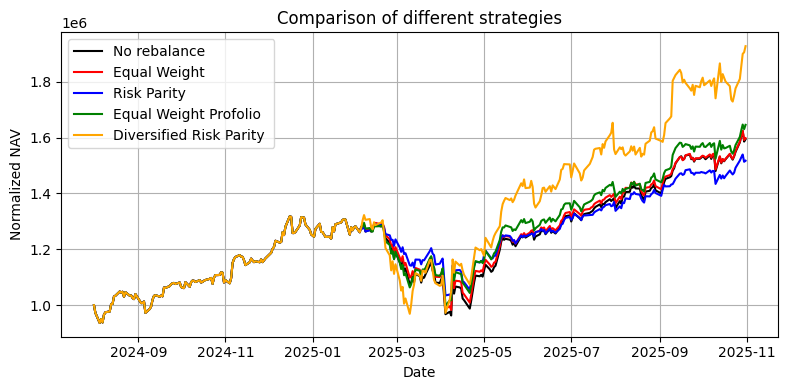

In [183]:
# Plot
plt.figure(figsize=(8,4))
plt.plot(nav_n['Date'], nav_n['Original_NAV'], label='No rebalance', color='black')
plt.plot(nav_1['Date'], nav_1['EqualWeight_NAV'], label='Equal Weight', color='red')
plt.plot(nav_2['Date'], nav_2['RiskParity_NAV'], label='Risk Parity', color='blue')
plt.plot(nav_3['Date'], nav_3['EWP_NAV'], label='Equal Weight Profolio', color='green')
plt.plot(nav_4['Date'], nav_4['DRP_NAV'], label='Diversified Risk Parity ', color='orange')
plt.title('Comparison of different strategies')
plt.xlabel('Date')
plt.ylabel('Normalized NAV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# (15) Compare the strategies by computing parameters

In [185]:
nav_dict = {
    'No rebalance': nav_n.set_index('Date')['Original_NAV'],
    'Equal Weight': nav_1.set_index('Date')['EqualWeight_NAV'],
    'Risk Parity': nav_2.set_index('Date')['RiskParity_NAV'],
    'Equal Weight Portfolio': nav_3.set_index('Date')['EWP_NAV'],
    'Diversified Risk Parity': nav_4.set_index('Date')['DRP_NAV']
}

summary = []
for name, nav in nav_dict.items():
    nav_cut = nav[nav.index > "2025-02-02"]
    ret = nav_cut.pct_change().dropna()
    summary.append({
        'Strategy': name,
        'Gain': nav_cut.iloc[-1] / nav.iloc[0],
        'StdDev': ret.std() * np.sqrt(252),
        'MinVal': nav_cut.min() / nav.iloc[0]
    })

result = pd.DataFrame(summary)
print(result.round(3))

                  Strategy   Gain  StdDev  MinVal
0             No rebalance  1.594   0.301   0.963
1             Equal Weight  1.598   0.286   0.983
2              Risk Parity  1.517   0.246   1.026
3   Equal Weight Portfolio  1.645   0.283   0.999
4  Diversified Risk Parity  1.927   0.386   0.969


Based on the out-of-sample period (1 August 2025 – 31 October 2025), the four strategy variants exhibit the following risk-return profile:

1. **No Rebalance & Equal Weight**  
   Gain ≈ 59%, volatility ≈ 30%, minimum value 96%.  
   Passive, market-following exposure with no risk control; highest realised risk.

2. **Equal Weight**  
   Gain ≈ 60%, volatility ≈ 29%, minimum value 98%.  
   Nearly identical to the no-rebalance case, confirming that a single rebalancing event in February 2025 provided little risk reduction during this short forward test.

3. **Risk Parity**  
   Gain ≈ 52%, volatility ≈ 25%, minimum value 103%.  
   Lowest annualised volatility and the only strategy that never dipped below its starting value, demonstrating consistent downside resilience.

4. **Equal Weight Portfolio (PCA)**  
   Gain ≈ 65%, volatility ≈ 28%, minimum value 100%.  
   Mid-range volatility with the second-highest return, offering a balanced risk-return trade-off.

5. **Diversified Risk Parity**  
   Gain ≈ 93%, volatility ≈ 39%, minimum value 97%.  
   Delivers the highest terminal wealth but at the cost of the largest short-term swings; drawdown is contained but oscillations are pronounced.

**Conclusion**  
- Return-seeking investors may still favour Diversified Risk Parity, provided they can tolerate higher volatility.  
- Those prioritising stability and downside protection should continue to prefer Risk Parity or the Principal-Component Equal Weight approach.  
- Passive equal-weight or no-rebalancing options remain suitable for investors content with market-average outcomes and minimal intervention.

# (16) Test strategies

In [206]:
# Initial condition
cash = 1_000_000
weights = pd.DataFrame(index=prices.index, columns=tickers)
shares  = pd.DataFrame(index=prices.index, columns=tickers)
nav = pd.Series(index=prices.index, name='EqualWeight_NAV')

# Open position
first_day = prices.index[0]
shares.loc[first_day] = (cash * 0.1) / prices.loc[first_day]
weights.loc[first_day] = 0.1
nav.loc[first_day] = (shares.loc[first_day] * prices.loc[first_day]).sum()

for t in prices.index[1:]:
    # Inheriting yesterday's share count
    shares.loc[t] = shares.iloc[shares.index.get_loc(t)-1]
    # Calculate today's market capitalization & weighting
    values = shares.loc[t] * prices.loc[t]
    nav.loc[t] = values.sum()
    weights.loc[t] = values / nav.loc[t]

    # Rebalancing Day: Bring the weights back to 10%.
    if t.strftime('%Y-%m-%d') == "2025-08-01": # the 1st trading day after 2/2/2025
        target_value = nav.loc[t] * 0.1
        shares.loc[t] = target_value / prices.loc[t]   # New target share count
        weights.loc[t] = 0.1

nav = nav.reset_index().rename(columns={'index': 'Date'})
nav_1 = nav

print('Previous day\'s weights (2025-07-31):')
print(weights.loc['2025-07-31'].apply(lambda x: f'{x:.1%}'))
print('\nEqual Weight\'s weights (2025-08-01):')
print(weights.loc["2025-08-01"].apply(lambda x: f'{x:.1%}'))

Previous day's weights (2025-07-31):
NVDA     11.8%
AAPL      6.9%
MSFT      9.3%
GOOGL     8.2%
AMZN      9.2%
AVGO     14.6%
META     11.3%
TSLA     10.3%
BRK-B     7.9%
JPM      10.5%
Name: 2025-07-31 00:00:00, dtype: object

Equal Weight's weights (2025-08-01):
NVDA     10.0%
AAPL     10.0%
MSFT     10.0%
GOOGL    10.0%
AMZN     10.0%
AVGO     10.0%
META     10.0%
TSLA     10.0%
BRK-B    10.0%
JPM      10.0%
Name: 2025-08-01 00:00:00, dtype: object


In [208]:
# Initial condition
cash = 1_000_000
weights = pd.DataFrame(index=prices.index, columns=tickers)
shares  = pd.DataFrame(index=prices.index, columns=tickers)
nav = pd.Series(index=prices.index, name='RiskParity_NAV')

# Open position
first_day = prices.index[0]
shares.loc[first_day] = (cash * 0.1) / prices.loc[first_day]
weights.loc[first_day] = 0.1
nav.loc[first_day] = (shares.loc[first_day] * prices.loc[first_day]).sum()

for t in prices.index[1:]:
    # Inheriting yesterday's share count
    shares.loc[t] = shares.iloc[shares.index.get_loc(t)-1]
    # Calculate today's market capitalization & weighting
    values = shares.loc[t] * prices.loc[t]
    nav.loc[t] = values.sum()
    weights.loc[t] = values / nav.loc[t]

    # Rebalancing Day
    if t.strftime('%Y-%m-%d') == "2025-08-01":
        # std is calculated using only data before 1/8/2025.
        sigma = np.log(prices / prices.shift(1)).dropna()[:t].std() # [:t]
        # Risk parity weight: 1/σ, Normalized
        weights_rp = (1 / sigma) / (1 / sigma).sum()
        # Reallocate capital
        total_value = nav.loc[t]
        shares.loc[t] = (total_value * weights_rp) / prices.loc[t]
        weights.loc[t] = weights_rp

nav = nav.reset_index().rename(columns={'index': 'Date'})
nav_2 = nav

print('\nRisk Parity\'s weights (2025-08-01):')
print(weights.loc["2025-08-01"].apply(lambda x: f'{x:.1%}'))


Risk Parity's weights (2025-08-01):
NVDA      6.2%
AAPL     10.7%
MSFT     13.5%
GOOGL    10.7%
AMZN      9.6%
AVGO      5.9%
META      9.3%
TSLA      4.7%
BRK-B    17.2%
JPM      12.1%
Name: 2025-08-01 00:00:00, dtype: object


In [210]:
log_ret = log_ret_0.loc['2024-08-01':'2025-07-31']
corr_mtx = log_ret.corr()
corr_vals = corr_mtx.values
eig_vals, eig_vecs = np.linalg.eigh(corr_vals)

desc_idx = np.argsort(eig_vals)[::-1]
eig_vals_sorted  = eig_vals[desc_idx]
eig_vecs_sorted  = eig_vecs[:, desc_idx]

sign_corrected = eig_vecs_sorted[:, :N] * signs

total_w = sign_corrected.sum(axis=1) / N 
total_w /= total_w.sum()

# Initial condition
cash = 1_000_000
weights = pd.DataFrame(index=prices.index, columns=tickers)
shares  = pd.DataFrame(index=prices.index, columns=tickers)
nav = pd.Series(index=prices.index, name='EWP_NAV')

# Open position
first_day = prices.index[0]
shares.loc[first_day] = (cash * 0.1) / prices.loc[first_day]
weights.loc[first_day] = 0.1
nav.loc[first_day] = (shares.loc[first_day] * prices.loc[first_day]).sum()

weight_s = pd.Series(total_w, index=tickers) 

for t in prices.index[1:]:
    # Inheriting yesterday's share count
    shares.loc[t] = shares.iloc[shares.index.get_loc(t)-1]
    # Calculate today's market capitalization & weighting
    values = shares.loc[t] * prices.loc[t]
    nav.loc[t] = values.sum()
    weights.loc[t] = values / nav.loc[t]

    # Rebalancing Day
    if t.strftime('%Y-%m-%d') == "2025-08-01":
        # Reallocate capital
        total_value = nav.loc[t]
        shares.loc[t] = (total_value * weight_s) / prices.loc[t]
        weights.loc[t] = weight_s

nav = nav.reset_index().rename(columns={'index': 'Date'})
nav_3 = nav

print('\nEWP\'s weights (2025-08-01):')
print(weights.loc["2025-08-01"].apply(lambda x: f'{x:.1%}'))




EWP's weights (2025-08-01):
NVDA     12.2%
AAPL      3.3%
MSFT      1.0%
GOOGL    -3.7%
AMZN      2.3%
AVGO     14.1%
META     -1.6%
TSLA     13.1%
BRK-B    30.6%
JPM      28.7%
Name: 2025-08-01 00:00:00, dtype: object


In [211]:
sign_corrected = eig_vecs_sorted[:, :N] * signs # eig_vecs_sorted here is computed base on data before 1/8/2025

pc_risk_w = 1 / eig_vals_sorted[:N]
pc_risk_w /= pc_risk_w.sum()

total_w = (sign_corrected * pc_risk_w).sum(axis=1)
total_w /= total_w.sum()

# Initial condition
cash = 1_000_000
weights = pd.DataFrame(index=prices.index, columns=tickers)
shares  = pd.DataFrame(index=prices.index, columns=tickers)
nav = pd.Series(index=prices.index, name='DRP_NAV')

# Open position
first_day = prices.index[0]
shares.loc[first_day] = (cash * 0.1) / prices.loc[first_day]
weights.loc[first_day] = 0.1
nav.loc[first_day] = (shares.loc[first_day] * prices.loc[first_day]).sum()

weight_s = pd.Series(total_w, index=tickers) 

for t in prices.index[1:]:
    # Inheriting yesterday's share count
    shares.loc[t] = shares.iloc[shares.index.get_loc(t)-1]
    # Calculate today's market capitalization & weighting
    values = shares.loc[t] * prices.loc[t]
    nav.loc[t] = values.sum()
    weights.loc[t] = values / nav.loc[t]

    # Rebalancing Day
    if t.strftime('%Y-%m-%d') == "2025-08-01":
        # Reallocate capital
        total_value = nav.loc[t]
        shares.loc[t] = (total_value * weight_s) / prices.loc[t]
        weights.loc[t] = weight_s

nav = nav.reset_index().rename(columns={'index': 'Date'})
nav_4 = nav

print('\nDRP\'s weights (2025-08-01):')
print(weights.loc["2025-08-01"].apply(lambda x: f'{x:.1%}'))


DRP's weights (2025-08-01):
NVDA      40.4%
AAPL     -32.4%
MSFT     -29.3%
GOOGL    -47.8%
AMZN     -29.5%
AVGO      55.6%
META     -41.7%
TSLA      24.1%
BRK-B     82.7%
JPM       78.0%
Name: 2025-08-01 00:00:00, dtype: object


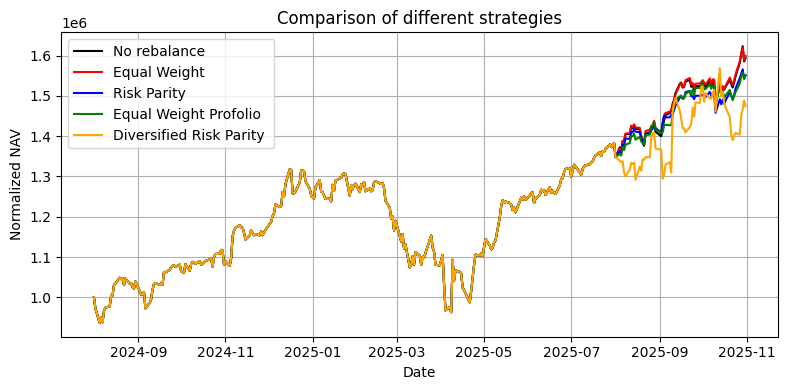

In [212]:
# Plot
plt.figure(figsize=(8,4))
plt.plot(nav_n['Date'], nav_n['Original_NAV'], label='No rebalance', color='black')
plt.plot(nav_1['Date'], nav_1['EqualWeight_NAV'], label='Equal Weight', color='red')
plt.plot(nav_2['Date'], nav_2['RiskParity_NAV'], label='Risk Parity', color='blue')
plt.plot(nav_3['Date'], nav_3['EWP_NAV'], label='Equal Weight Profolio', color='green')
plt.plot(nav_4['Date'], nav_4['DRP_NAV'], label='Diversified Risk Parity ', color='orange')
plt.title('Comparison of different strategies')
plt.xlabel('Date')
plt.ylabel('Normalized NAV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [213]:
nav_dict = {
    'No rebalance': nav_n.set_index('Date')['Original_NAV'],
    'Equal Weight': nav_1.set_index('Date')['EqualWeight_NAV'],
    'Risk Parity': nav_2.set_index('Date')['RiskParity_NAV'],
    'Equal Weight Portfolio': nav_3.set_index('Date')['EWP_NAV'],
    'Diversified Risk Parity': nav_4.set_index('Date')['DRP_NAV']
}

summary = []
for name, nav in nav_dict.items():
    nav_cut = nav[nav.index >= "2025-08-01"]
    ret = nav_cut.pct_change().dropna()
    summary.append({
        'Strategy': name,
        'Gain': nav_cut.iloc[-1] / nav.iloc[0],
        'StdDev': ret.std() * np.sqrt(252),
        'MinVal': nav_cut.min() / nav.iloc[0]
    })

result = pd.DataFrame(summary)
print(result.round(3))

                  Strategy   Gain  StdDev  MinVal
0             No rebalance  1.594   0.184   1.348
1             Equal Weight  1.599   0.172   1.348
2              Risk Parity  1.551   0.143   1.348
3   Equal Weight Portfolio  1.551   0.157   1.348
4  Diversified Risk Parity  1.474   0.396   1.292


The test confirmed the expected risk-return ordering: risk-parity variants again showed the lowest volatility, while the diversified risk-parity portfolio exhibited the highest fluctuation. All strategies remained above their starting values throughout the period, validating that the weight sets derived from the earlier sample successfully transferred to the different dataset without structural breakdown. Thus, the exercise can be considered successful.